### **1. Identifying Soil Zones**
The statistical characteristics of the four clusters are analyzed here. By looking at the mean values of original soil properties (pH, Organic Carbon, Sand %, etc.), meaningful names can be assigned to these zones.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv("../outputs/soil_clusters_top_3_models.csv")

CLUSTER_MODELS = {
    "K-Means": "cluster_kmeans",
    "Agglomerative": "cluster_agg",
    "GMM": "cluster_gmm"
}

SOIL_FEATURES = [
    "taw",
    "organic_carbon",
    "cec",
    "ph",
    "sand_pct"
]

for model_name, cluster_col in CLUSTER_MODELS.items():

    print("\n" + "="*60)
    print(f"{model_name} - Mean Soil Properties per Cluster")
    print("="*60)

    cluster_summary = (
        df_final
        .groupby(cluster_col)[SOIL_FEATURES]
        .mean()
        .round(2)
    )

    print(cluster_summary)


K-Means - Mean Soil Properties per Cluster
                 taw  organic_carbon    cec    ph  sand_pct
cluster_kmeans                                             
0               8.83            2.91  16.64  5.19     70.33
1               6.90            3.18   9.77  4.86     66.27
2               6.63            3.31  17.20  5.34     78.76
3               7.79            4.11  18.65  4.81     62.41

Agglomerative - Mean Soil Properties per Cluster
              taw  organic_carbon    cec    ph  sand_pct
cluster_agg                                             
0            7.71            4.06  18.65  4.85     63.54
1            8.83            2.89  16.67  5.20     70.84
2            6.89            3.18   9.77  4.86     66.28
3            6.54            3.16  16.55  5.41     80.58

GMM - Mean Soil Properties per Cluster
              taw  organic_carbon    cec    ph  sand_pct
cluster_gmm                                             
0            8.83            2.92  16.66  5.18    

In [12]:
print("Cluster Size Distribution\n")

for model_name, cluster_col in CLUSTER_MODELS.items():
    print("=" * 45)
    print(f"{model_name}")
    print("=" * 45)

    counts = df_final[cluster_col].value_counts().sort_index()
    pcts   = (counts / len(df_final) * 100).round(1)

    size_df = pd.DataFrame({
        "Pixels"    : counts,
        "Coverage %" : pcts
    })

    print(size_df)
    print(f"Total pixels: {len(df_final)}\n")

Cluster Size Distribution

K-Means
                Pixels  Coverage %
cluster_kmeans                    
0                  353        10.3
1                 1305        38.1
2                  524        15.3
3                 1240        36.2
Total pixels: 3422

Agglomerative
             Pixels  Coverage %
cluster_agg                    
0              1400        40.9
1               334         9.8
2              1306        38.2
3               382        11.2
Total pixels: 3422

GMM
             Pixels  Coverage %
cluster_gmm                    
0               356        10.4
1              1305        38.1
2               513        15.0
3              1248        36.5
Total pixels: 3422



The three models produce a consistent cluster size structure despite using different algorithms. Two dominant zones cover approximately 74-75% of the Western Province combined, one mid sized zone covers 11-15%, and one smaller zone covers approximately 10%. The near identical distributions of K-Means and GMM, and the matching proportions in Agglomerative despite different cluster ID assignments, confirm that the 4 cluster structure is stable and not algorithm dependent.

### **2. Visualizing the Differences**

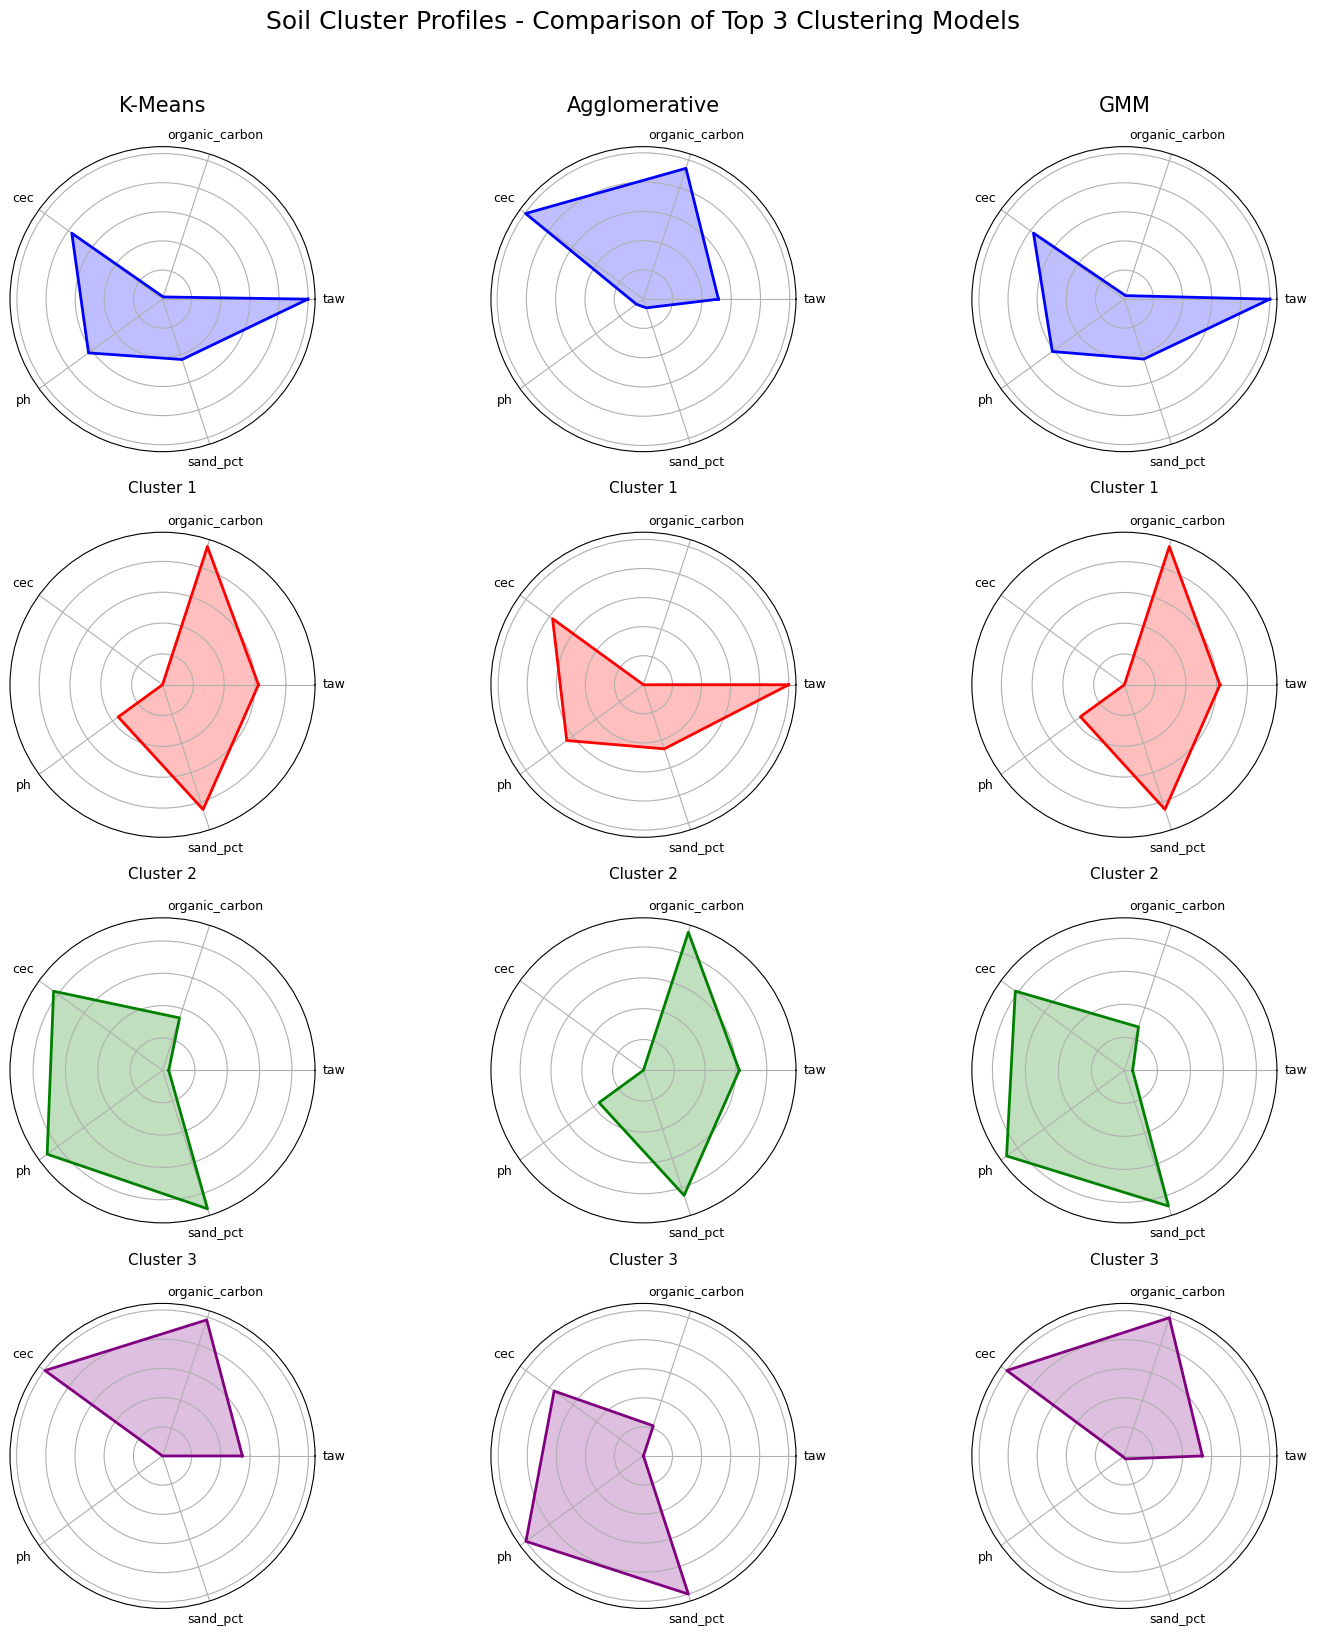

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Radar chart helper
def make_radar_chart(ax, df, cluster_id, color):
    labels = df.columns
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    values = df.loc[cluster_id].tolist()
    values += values[:1]

    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, values, color=color, linewidth=2)

    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f"Cluster {cluster_id}", fontsize=11, y=1.1)


# Compute all cluster summaries
all_summaries = {}
for model_name, cluster_col in CLUSTER_MODELS.items():
    all_summaries[model_name] = (
        df_final
        .groupby(cluster_col)[SOIL_FEATURES]
        .mean()
    )

# Fit scaler once on combined data from all models
scaler = MinMaxScaler()
combined = pd.concat(all_summaries.values())
scaler.fit(combined)

# Plot
colors = ['blue', 'red', 'green', 'purple']
n_models = len(CLUSTER_MODELS)

fig, axes = plt.subplots(
    4, n_models,
    figsize=(5 * n_models, 16),
    subplot_kw=dict(polar=True)
)

for col_idx, (model_name, cluster_col) in enumerate(CLUSTER_MODELS.items()):

    cluster_summary = all_summaries[model_name]

    # transform
    cluster_norm = pd.DataFrame(
        scaler.transform(cluster_summary),
        columns=cluster_summary.columns,
        index=cluster_summary.index
    )

    for row_idx, cluster_id in enumerate(cluster_norm.index):
        make_radar_chart(
            axes[row_idx, col_idx],
            cluster_norm,
            cluster_id,
            colors[row_idx]
        )

    axes[0, col_idx].set_title(
        model_name,
        fontsize=15,
        pad=25
    )

plt.suptitle(
    "Soil Cluster Profiles - Comparison of Top 3 Clustering Models",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

### **3. Spatial Distribution of Soil Clusters in the Western Province**

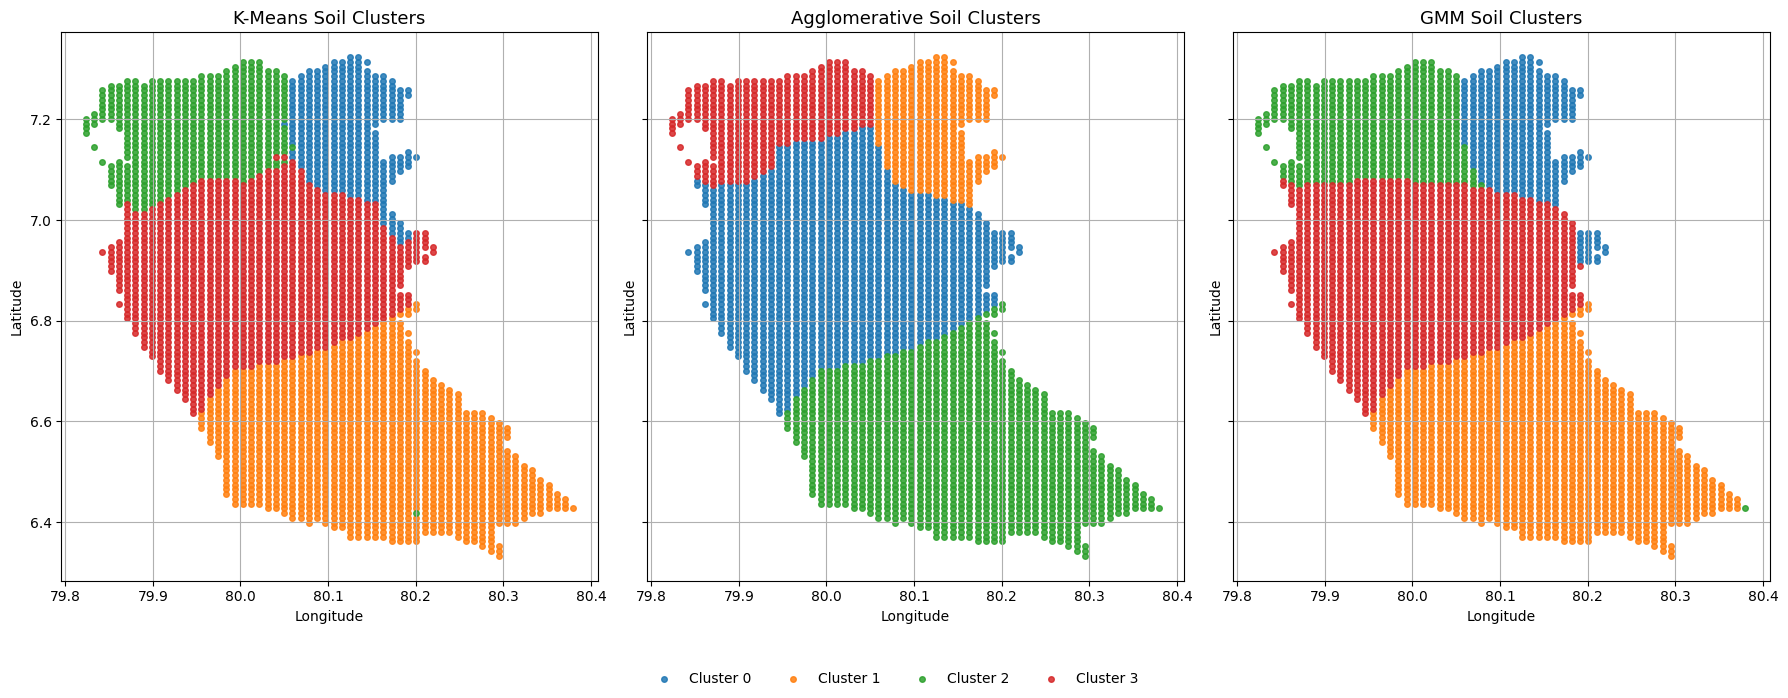

In [14]:
def plot_spatial_clusters_side_by_side(df, cluster_cols, titles):
    fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

    for ax, cluster_col, title in zip(axes, cluster_cols, titles):
        for c in sorted(df[cluster_col].unique()):
            subset = df[df[cluster_col] == c]
            ax.scatter(
                subset["lon"],
                subset["lat"],
                s=16,
                alpha=0.85,
                label=f"Cluster {c}"
            )

        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True)

    # Single legend for all plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

plot_spatial_clusters_side_by_side(
    df_final,
    cluster_cols=[
        "cluster_kmeans",
        "cluster_agg",
        "cluster_gmm"
    ],
    titles=[
        "K-Means Soil Clusters",
        "Agglomerative Soil Clusters",
        "GMM Soil Clusters"
    ]
)

In [15]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

models = list(CLUSTER_MODELS.keys())
cols   = list(CLUSTER_MODELS.values())

print("Inter-Model Agreement\n")
print(f"{'Pair':<40} {'ARI':>7}  {'NMI':>7}")
print("-" * 58)

for i in range(len(models)):
    for j in range(i + 1, len(models)):
        ari = adjusted_rand_score(df_final[cols[i]], df_final[cols[j]])
        nmi = normalized_mutual_info_score(df_final[cols[i]], df_final[cols[j]])
        pair = f"{models[i]} vs {models[j]}"
        print(f"{pair:<40} {ari:>7.3f}   {nmi:>7.3f}")

Inter-Model Agreement

Pair                                         ARI      NMI
----------------------------------------------------------
K-Means vs Agglomerative                   0.897     0.886
K-Means vs GMM                             0.934     0.894
Agglomerative vs GMM                       0.902     0.889


**Inter-Model Agreement Interpretation:**

| Pair | ARI | NMI |
|------|-----|-----|
| K-Means vs Agglomerative | 0.897 | 0.886 |
| K-Means vs GMM | 0.934 | 0.894 |
| Agglomerative vs GMM | 0.902 | 0.889 |

ARI measures cluster assignment agreement corrected for chance (1.0 = perfect agreement, 0.0 = random). NMI measures shared information between two clusterings (1.0 = identical, 0.0 = no shared structure).

All three pairs show ARI above 0.89 and NMI above 0.88, indicating near identical cluster assignments across all three models. The highest agreement is between K-Means and GMM (ARI=0.934), consistent with the near identical pixel count distributions observed above. The slightly lower agreement involving Agglomerative reflects minor boundary differences arising from its hierarchical paradigm, but the disagreement affects fewer than 11% of pixels at most. Together these scores provide strong quantitative confirmation that the 4 cluster structure is algorithm independent and reflects genuine structure in the Western Province soil data.